<Figure size 1200x500 with 0 Axes>

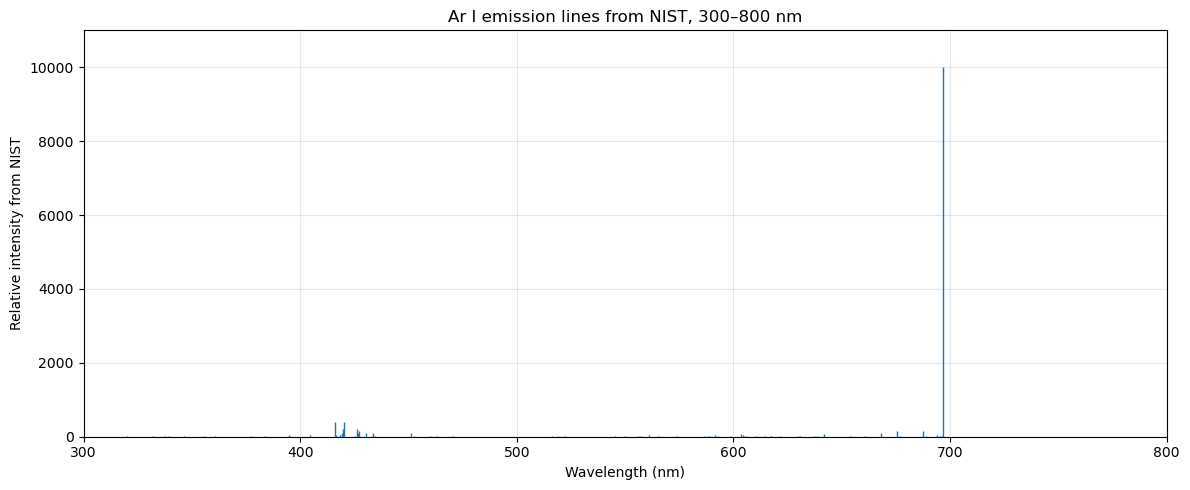

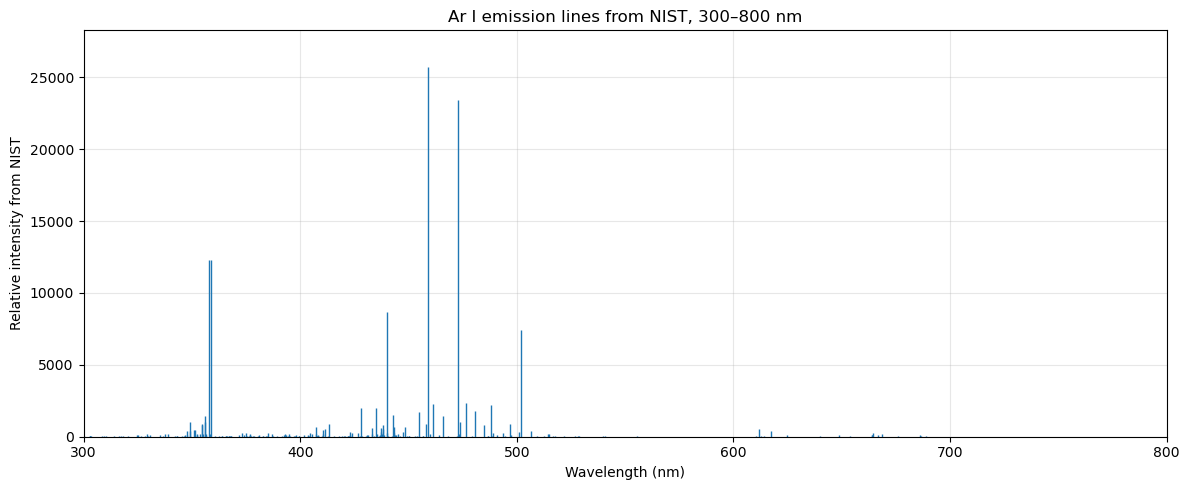

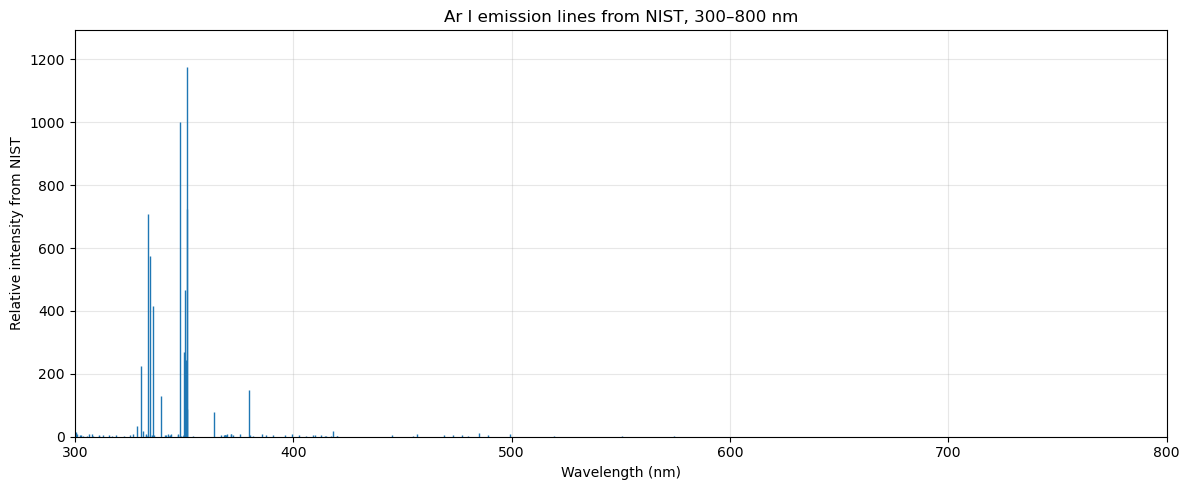

In [6]:
# pip install astroquery astropy numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from astroquery.nist import Nist
import astropy.units as u
from nist_utils import ExtractIntensityNist


# Different ionization states to download
ar_types = ["Ar I", "Ar II", "Ar III"]
# One color for each ionization state
colors = ["tab:blue", "tab:red", "tab:green"]

plt.figure(figsize=(12, 5))

for ar_type, color in zip(ar_types, colors):

    table = Nist.query(
        250*u.nm , 
        700*u.nm , 
        linename = ar_type, 
        wavelength_type='vacuum')

    # Wavelength column is usually "Observed" or "Ritz"
    wl_col = "Observed" if "Observed" in table.colnames else "Ritz"
    int_col = "Rel." if "Rel." in table.colnames else None

    # Convert wavelengths to float
    wl = np.array(table[wl_col], dtype=float)

    # Remove invalid wavelengths
    mask = np.isfinite(wl)
    wl = wl[mask]
    table = table[mask]

    # Relative intensities, if available
    if int_col is not None:
        intensity = ExtractIntensityNist(table[int_col])
        #intensity = np.array(table[int_col], dtype=float)
    else:
        intensity = np.ones_like(wl)

    # if int_col is not None:
    #     intensity = np.array(table[int_col], dtype=float)
    #     intensity[~np.isfinite(intensity)] = 1
    # else:
    #     intensity = np.ones_like(wl)

    # Sort by wavelength
    idx = np.argsort(wl)
    wl = wl[idx]
    intensity = intensity[idx]


    # Plot spectral lines
    plt.figure(figsize=(12, 5))

    for l, I in zip(wl, intensity):
        plt.vlines(l, 0, I, linewidth=1)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Relative intensity from NIST")
    plt.title("Ar I emission lines from NIST, 300–800 nm")
    plt.xlim(300, 800)
    plt.ylim(0, 1.1 * np.nanmax(intensity))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Exception: Result did not contain a table

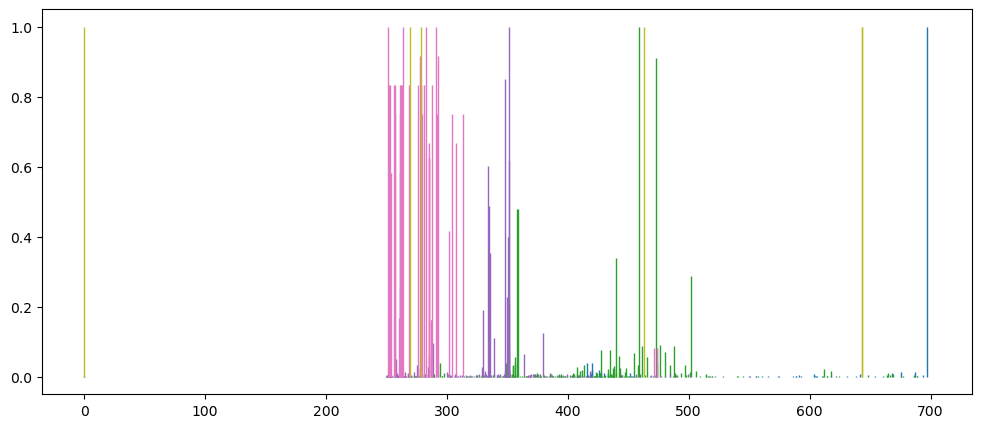

In [ ]:
# pip install astroquery astropy numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from astroquery.nist import Nist
import astropy.units as u

from nist_utils import ExtractIntensityNist

# Different ionization states to download
ar_types = ["Ar I", "Ar II", "Ar III", "Ar IV", "Ar V"]

# One color for each ionization state
# Use automatic colors
colors = plt.cm.tab10(np.linspace(0, 1, len(ar_types)))

plt.figure(figsize=(12, 5))

for ar_type, color in zip(ar_types, colors):

    print(f"Downloading {ar_type} lines...")

    table = Nist.query(
        250*u.nm,
        700*u.nm,
        linename=ar_type,
        wavelength_type='vacuum'
    )

    # Wavelength column
    wl_col = "Observed" if "Observed" in table.colnames else "Ritz"

    # Intensity column
    int_col = "Rel." if "Rel." in table.colnames else None

    # Convert wavelengths
    wl = np.array(table[wl_col], dtype=float)

    # Remove invalid wavelengths
    mask = np.isfinite(wl)
    wl = wl[mask]
    table = table[mask]

    # Intensities
    if int_col is not None:
        intensity = ExtractIntensityNist(table[int_col])
    else:
        intensity = np.ones_like(wl)

    # Remove invalid intensities
    intensity[~np.isfinite(intensity)] = 1

    # Sort
    idx = np.argsort(wl)
    wl = wl[idx]
    intensity = intensity[idx]

    # Normalize each species independently
    intensity = intensity / np.max(intensity)

    # Plot spectral lines
    for l, I in zip(wl, intensity):
        plt.vlines(l, 0, I, color=color, linewidth=1)

    # Dummy line for legend
    plt.plot([], [], color=color, label=ar_type)

# Final figure formatting
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized relative intensity")
plt.title("Argon emission lines from NIST")
plt.xlim(250, 700)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()